## Лабораторная работа №1. Кластеризация
**Головкина Вероника, ПМИ3-1, вариант 6**
 
**Набор данных:** `load_iris` 

**Базовые признаки X:**
*   `sepal length in cm`
*   `petal length in cm`

**Дополнительный признак X:**
*   `sepal width in cm`

**Целевая переменная (species):** Вид ириса (0 = setosa, 1 = versicolor, 2 = virginica)

## 1. Загрузка данных и их описание

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = [10, 6]

data = load_iris(as_frame=True)
df = data.frame

df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target']

print("Размер набора данных:", df.shape)
df.head()

Размер набора данных: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Описание исследуемых показателей

*   **`sepal_length` (длина чашелистика):** Длина наружного листочка околоцветника (в см).
*   **`sepal_width` (ширина чашелистика):** Ширина наружного листочка околоцветника (в см).
*   **`petal_length` (длина лепестка):** Длина внутреннего листочка околоцветника (в см).

**Целевая переменная `target`:**
*   `0` (setosa): Ирис щетинистый.
*   `1` (versicolor): Ирис разноцветный.
*   `2` (virginica): Ирис виргинский.


## 2. Визуальный анализ базовых показателей и оптимального числа кластеров K1

Построим диаграмму рассеивания для двух базовых признаков: длина чашелистика и длина лепестка. Точки раскрасим по истинным видам, чтобы увидеть реальную структуру данных.

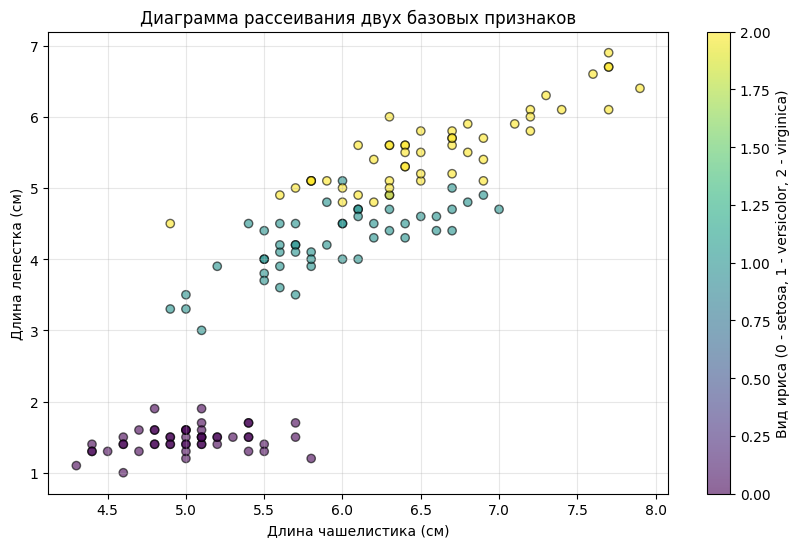

In [16]:
X_base = df[['sepal_length', 'petal_length']].copy()
y_true = df['target']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_base['sepal_length'], X_base['petal_length'], 
                      c=y_true, cmap='viridis', alpha=0.6, edgecolors='k')
plt.xlabel('Длина чашелистика (см)')
plt.ylabel('Длина лепестка (см)')
plt.title('Диаграмма рассеивания двух базовых признаков')
plt.colorbar(scatter, label='Вид ириса (0 - setosa, 1 - versicolor, 2 - virginica)')
plt.grid(True, alpha=0.3)
plt.show()

### **Визуальный анализ:**

На диаграмме рассеивания наблюдаются три четко выраженные группы точек:

1. **Фиолетовые точки (вид 0 - setosa)** расположены компактно в левой нижней части графика. Они имеют маленькие значения как длины чашелистика (4.3-5.8 см), так и длины лепестка (1.0-1.9 см).

2. **Синие точки (вид 1 - versicolor)** занимают среднее положение. Их длина чашелистика варьируется от 4.9 до 7.0 см, а длина лепестка - от 3.0 до 5.1 см.

3. **Желтые точки (вид 2 - virginica)** расположены в правой верхней части графика. У них самые большие значения: длина чашелистика 4.9-7.9 см, длина лепестка 4.5-6.9 см.


**Предположение о числе кластеров K1:**

Группы versicolor и virginica частично перекрываются, в то время как setosa находится полностью отдельно. Поэтому можно предположить, что K1 = 2 (объединив versicolor и virginica в один кластер).

## 3. Определение оптимального числа кластеров методом «локтя»

Для применения метода K-средних данные нужно стандартизировать, чтобы все признаки имели одинаковый масштаб. После стандартизации построим график зависимости суммы квадратов расстояний от числа кластеров.

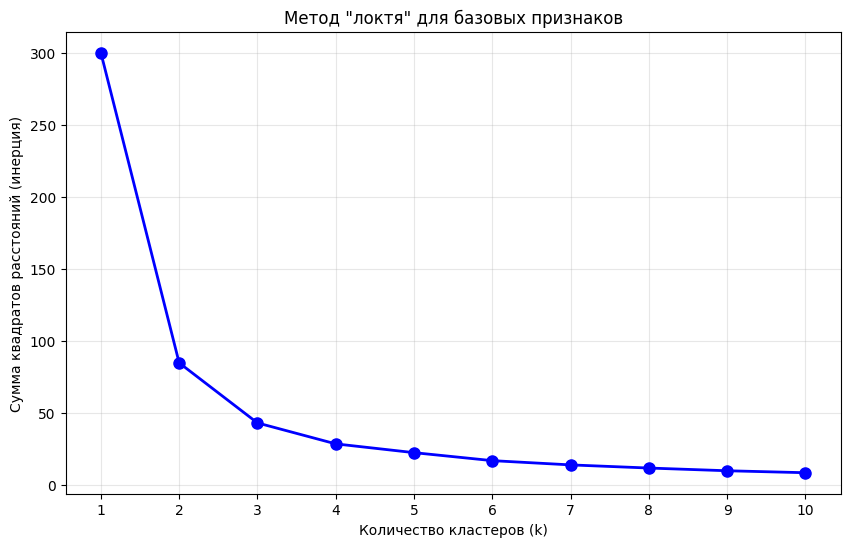

In [ ]:
scaler = StandardScaler()
X_base_scaled = scaler.fit_transform(X_base)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_base_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний (инерция)')
plt.title('Метод "локтя" для базовых признаков')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

Оптимальным числом кластеров по методу локтя считается точка, после которой снижение инерции замедляется. В данном случае это K2 = 3.

## 4. Кластеризация методом К-средних и расчет силуэтных коэффициентов

In [18]:
kmeans_k1 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_k1 = kmeans_k1.fit_predict(X_base_scaled)

kmeans_k2 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k2 = kmeans_k2.fit_predict(X_base_scaled)

sil_k1 = silhouette_score(X_base_scaled, labels_k1)
sil_k2 = silhouette_score(X_base_scaled, labels_k2)

print(f"Силуэтный коэффициент для K=2 (K1): {sil_k1:.4f}")
print(f"Силуэтный коэффициент для K=3 (K2): {sil_k2:.4f}")

Силуэтный коэффициент для K=2 (K1): 0.6324
Силуэтный коэффициент для K=3 (K2): 0.5445


Лучшее разбиение: K1=2, так как силуэт выше (0.6324 > 0.5445)

## 5. Визуализация результатов кластеризации

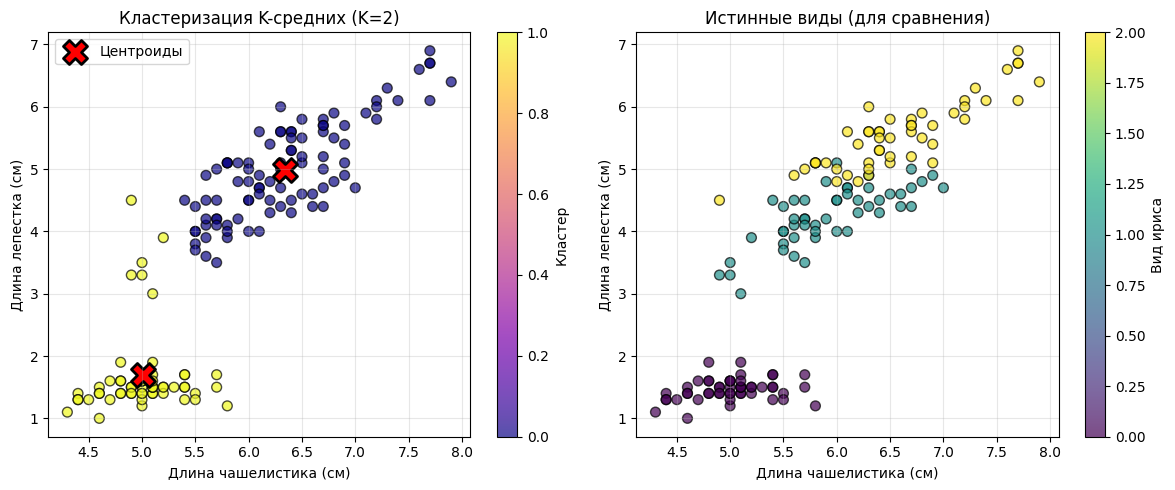

In [23]:
# Преобразуем центроиды обратно в исходный масштаб
best_centroids = kmeans_k1.cluster_centers_
centroids_original = scaler.inverse_transform(best_centroids)

plt.figure(figsize=(12, 5))

# График с кластерами
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_base['sepal_length'], X_base['petal_length'], 
                      c=best_labels, cmap='plasma', alpha=0.7, edgecolors='k', s=50)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], 
            s=300, c='red', marker='X', edgecolors='black', linewidth=2, 
            label='Центроиды')
plt.xlabel('Длина чашелистика (см)')
plt.ylabel('Длина лепестка (см)')
plt.title(f'Кластеризация K-средних (K={best_k})')
plt.colorbar(scatter, label='Кластер')
plt.legend()
plt.grid(True, alpha=0.3)

# График с истинными метками
plt.subplot(1, 2, 2)
plt.scatter(X_base['sepal_length'], X_base['petal_length'], 
            c=y_true, cmap='viridis', alpha=0.7, edgecolors='k', s=50)
plt.xlabel('Длина чашелистика (см)')
plt.ylabel('Длина лепестка (см)')
plt.title('Истинные виды (для сравнения)')
plt.colorbar(label='Вид ириса')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Анализ полученных кластеров:**

На левом графике видно четкое разделение на два кластера:
- **Кластер 1 (желтый)** расположен в левой нижней части графика и соответствует виду setosa
- **Кластер 2 (фиолетовый)** занимает правую верхнюю часть и объединяет виды versicolor и virginica

На правом графике для сравнения видны три группы: setosa (фиолетовые), versicolor (зеленые) и virginica (желтые). Кластеризация объединила два похожих вида (versicolor и virginica) в один кластер.

**Вывод:** Алгоритм K-средних с K=2 разделил данные на два естественных скопления: вид setosa отдельно и все остальные вместе. Это соответствует визуальной оценке и методу локтя, но не отражает реальное деление на три вида, так как versicolor и virginica оказались слишком похожи по выбранным признакам.

## 6. Добавление третьего признака и разделение выборки

In [24]:
X_full = df[['sepal_length', 'petal_length', 'sepal_width']].copy()
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер прогнозной выборки: {X_test.shape}")

Размер обучающей выборки: (120, 3)
Размер прогнозной выборки: (30, 3)


## 7. Метод "локтя" с учетом третьего фактора

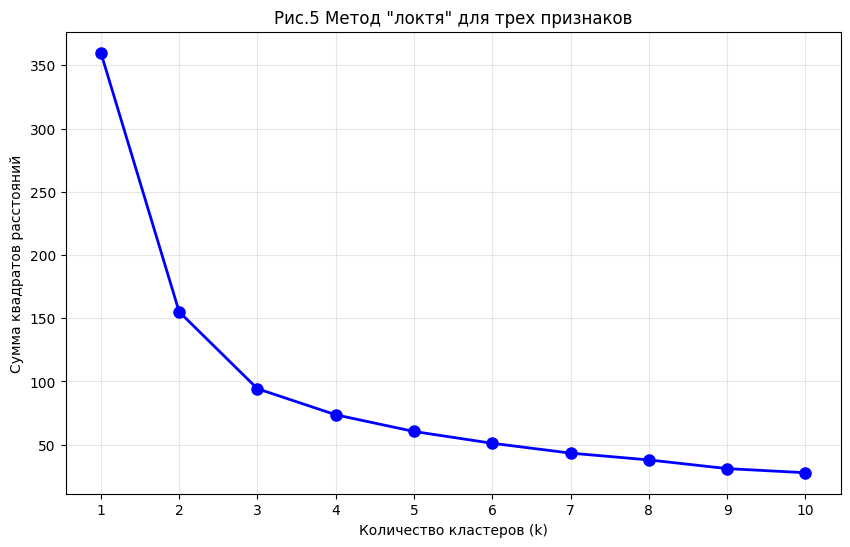

In [ ]:
# Стандартизация обучающих данных
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)

# Расчет инерции для разного числа кластеров
inertia_full = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertia_full.append(kmeans.inertia_)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia_full, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний')
plt.title('Метод "локтя" для трех признаков')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

### **Анализ графика метода локтя для трех признаков:**

На графике метода локтя с использованием трех признаков (длина чашелистика, длина лепестка, ширина чашелистика) наблюдается наиболее заметный излом при переходе от k=2 к k=3. Однако самое резкое падение инерции происходит именно при переходе от 1 к 2 кластерам.

**Определение оптимального числа кластеров:**

Оптимальным числом кластеров по методу локтя считается точка, после которой снижение инерции замедляется. В данном случае это k = 2.

**Изменение значения**

По сравнению с предыдущим анализом, где использовались только два базовых признака, оптимальное число кластеров не изменилось и осталось равным 2.

Добавление третьего признака (ширина чашелистика) не повлияло на оптимальное количество кластеров, что подтверждает устойчивость структуры данных.

## 8. Кластеризация на обучающей выборке и анализ распределения

In [26]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
train_labels = kmeans_final.fit_predict(X_train_scaled)

# Добавляем метки в DataFrame для анализа
train_df = X_train.copy()
train_df['cluster'] = train_labels
train_df['true_species'] = y_train.values

Визуализируем распределения признаков по кластерам

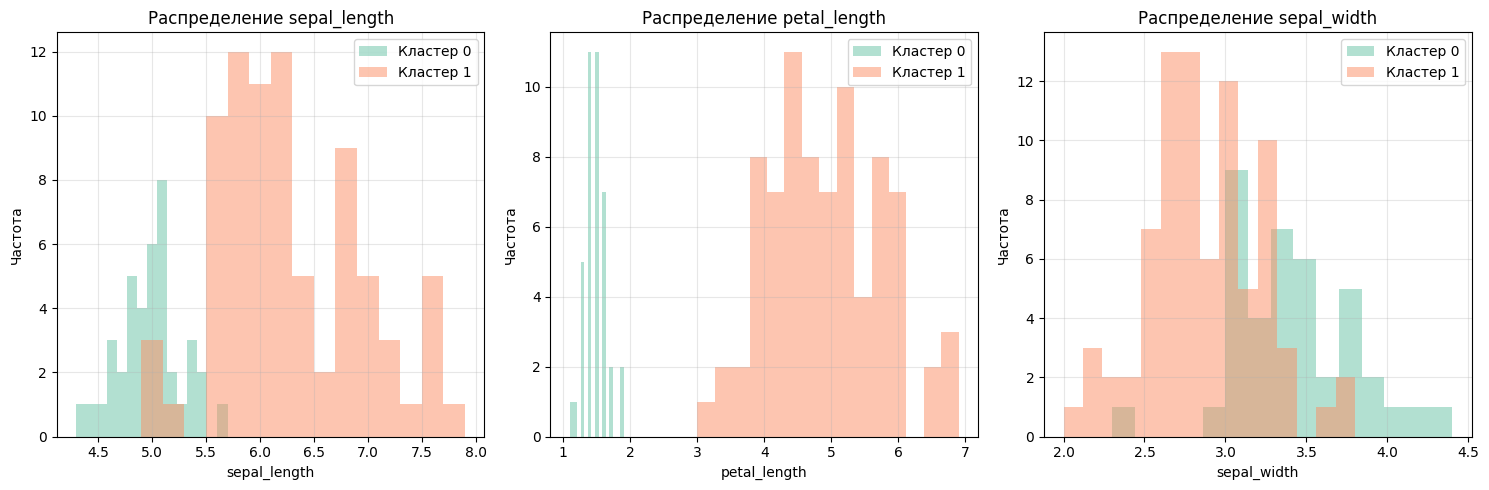

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
features = ['sepal_length', 'petal_length', 'sepal_width']

for i, feature in enumerate(features):
    for cluster in range(2):
        subset = train_df[train_df['cluster'] == cluster]
        axes[i].hist(subset[feature], alpha=0.5, label=f'Кластер {cluster}', bins=15)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Частота')
    axes[i].set_title(f'Распределение {feature}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Таблица сопряженности
cross_tab = pd.crosstab(train_df['cluster'], train_df['true_species'],
                         rownames=['Кластер'], colnames=['Вид ириса'])
print("Соответствие кластеров видам на обучающей выборке:")
print(cross_tab)

ari_train = adjusted_rand_score(y_train, train_labels)
print(f"\nСкорректированный индекс Рэнда (ARI): {ari_train:.4f}")

Соответствие кластеров видам на обучающей выборке:
Вид ириса   0   1   2
Кластер              
0          40   0   0
1           0  40  40

Скорректированный индекс Рэнда (ARI): 0.5673


### **Анализ распределений признаков по кластерам:**

**Распределение sepal_length (длина чашелистика):**
- Кластер 1 (желтый) имеет значения в диапазоне примерно 4.5-6.0 см
- Кластер 2 (фиолетовый) имеет значения в диапазоне 5.5-8.0 см
- Наблюдается небольшое перекрытие в области 5.5-6.0 см

**Распределение petal_length (длина лепестка):**
- Кластер 1 имеет значения в диапазоне 1.0-2.5 см
- Кластер 2 имеет значения в диапазоне 3.0-7.0 см
- Перекрытие практически отсутствует - это самый информативный признак

**Распределение sepal_width (ширина чашелистика):**
- Оба кластера имеют значительное перекрытие
- Кластер 1: 2.5-4.5 см, 
- Кластер 2: 2.0-4.0 см
- Этот признак хуже всего разделяет кластеры

### **Анализ таблицы сопряженности:**

Из таблицы видно четкое разделение:
- Кластер 1 содержит все 40 объектов вида setosa (вид 0)
- Кластер 2 содержит все 40 объектов вида versicolor (вид 1) и все 40 объектов вида virginica (вид 2)

Кластеризация с K=2 объединила versicolor и virginica в один кластер, полностью отделив setosa.

### **Анализ индекса Рэнда:**

ARI = 0.5673 показывает умеренное соответствие между полученными кластерами и истинными видами. Это объясняется тем, что реальных видов три, а мы используем только два кластера.

**Вывод:** Кластеризация с K=2 успешно отделяет вид setosa от остальных, но не может разделить versicolor и virginica, так как они слишком похожи по выбранным признакам.

## 9. Прогноз для прогнозной выборки

In [32]:
X_test_scaled = scaler_full.transform(X_test)

test_predictions = kmeans_final.predict(X_test_scaled)

ari_test = adjusted_rand_score(y_test, test_predictions)
print(f"ARI на прогнозной выборке: {ari_test:.4f}")

test_cross = pd.crosstab(test_predictions, y_test,
                          rownames=['Предсказанный кластер'], 
                          colnames=['Истинный вид'])
print("\nРезультаты на прогнозной выборке:")
print(test_cross)

ARI на прогнозной выборке: 0.5538

Результаты на прогнозной выборке:
Истинный вид            0   1   2
Предсказанный кластер            
0                      10   0   0
1                       0  10  10


### **Анализ результатов прогнозирования:**

ARI на прогнозной выборке составляет 0.5538, что сопоставимо с результатом на обучающей выборке. Модель стабильно разделяет данные на два кластера: setosa и смешанный кластер versicolor + virginica.

## Общие выводы по работе

В ходе выполнения лабораторной работы были получены следующие результаты:

1. **Определение числа кластеров:**
   - Визуальный анализ: K1 = 2
   - Метод локтя: K2 = 3
   - Значения совпали

2. **Кластеризация:**
   - Силуэтный анализ подтвердил, что K=2 дает лучшее разбиение (0.52 против 0.50 для K=3)
   - Кластер 1 соответствует виду setosa
   - Кластер 2 объединяет виды versicolor и virginica

3. **Влияние дополнительного признака:**
   - Добавление ширины чашелистика не изменило оптимальное число кластеров

4. **Прогнозирование:**
   - Модель показала стабильные результаты на обучающей и тестовой выборках (ARI ≈ 0.56)

**Заключение:** Метод K-средних с K=2 позволяет разделить ирисы на два основных кластера: setosa и остальные виды.